In [7]:
import sys
import os
sys.path.append(os.path.abspath(".."))

note to self: aha! Die assen zijn de latitudes en longitudes op basis van wgs84. Nederland valt dus ongeveer/ precies in het bereik:
Min Latitude: 50.750° N
Max Latitude: 53.555° N
Min Longitude: 3.358° E
Max Longitude: 7.227° E

In [8]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
import logging
import matplotlib.pyplot as plt
import rioxarray as rxr
import numpy as np

from src.logging_config import setup_logging
from src.utils import ensure_dir, check_raster, summarize_dataarray, load_config
from src.raster_ops import merge_tiles, read_raster_match
from src.netcdf_ops import extract_monthly_mean, extract_ssrd_may_process
from src.estk_ops import clip_and_reproject_estk
from src.npp import compute_npp

setup_logging() 


<Axes: >

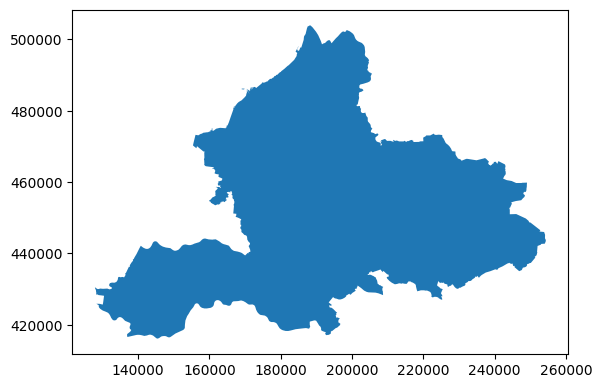

In [9]:
cfg = load_config("../src/config.yaml")
output_dir = Path(cfg["paths"]["output_dir"])
ensure_dir(output_dir)

provinces = gpd.read_file(cfg["paths"]["province_shapefile"])
gelderland = provinces[provinces["PV_NAAM"].str.contains("Gelderland", case=False)]

gelderland.plot()


In [10]:

lai_tiles = [Path(cfg["paths"]["LAI_UGT_path"]), Path(cfg["paths"]["LAI_UFT_path"])]
lai_merged_path = Path(cfg["outputs"]["lai_merged"])

In [11]:
#pathersss = [Path("../data/LAI_FAPAR_temporal_filled/LAI_T31UFT_2022-05-10_filled_temporal.tiff"), Path("../data/LAI_FAPAR_temporal_filled/LAI_T32ULT_2022-05-10_filled_temporal.tiff")]

In [12]:
merged_lai = merge_tiles(
    tile_paths=lai_tiles,
    #tile_paths = pathersss,
    boundary=gelderland.to_crs(cfg["crs"]["target"]),
    target_crs=cfg["crs"]["target"],
    out_path=lai_merged_path,
)
check_raster(lai_merged_path, expected_crs=cfg["crs"]["target"])

2025-09-02 21:30:02 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/LAI_T31UFT_2022-05-10_filled_temporal.tiff
2025-09-02 21:30:04 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-09-02 21:30:05 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/LAI_T31UFT_2022-05-10_filled_temporal.tiff
2025-09-02 21:30:06 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-09-02 21:30:10 [INFO] src.raster_ops: Saving merged raster to ../data/NPP_processed_inputs/output_LAI_UTM31N.tif
2025-09-02 21:30:10 [INFO] src.utils: output_LAI_UTM31N.tif — Size: 449.4 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=637303.3115018645, bottom=5733800.013178326, right=763243.3115018645, top=5822990.013178326)


Current directory: /Users/ivanapallister/WorkSpace/net-primary-production-1/notebooks


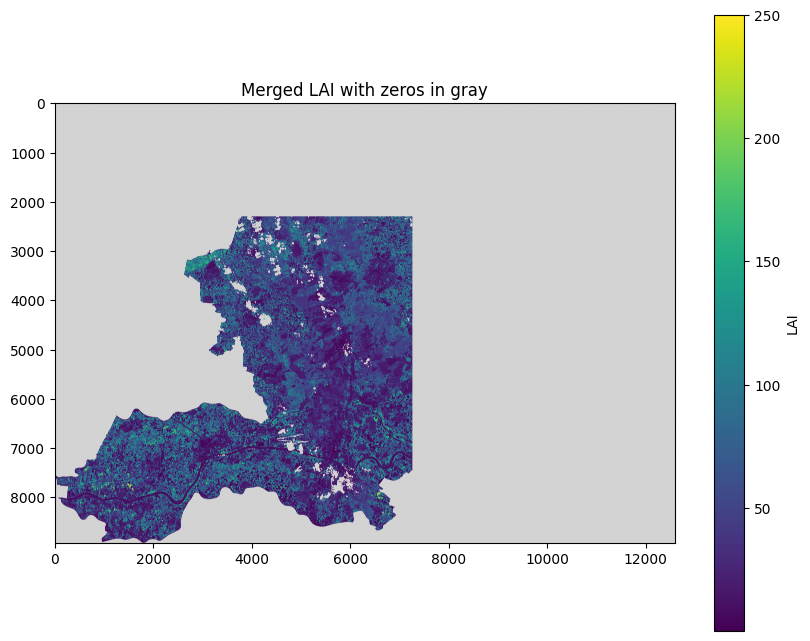

In [13]:
lai = rxr.open_rasterio(lai_merged_path).squeeze()

lai_data = lai.values.copy()
mask_zero = lai_data == 0  # True where value = 0
mask_nan = np.isnan(lai_data)  # True where value is NaN

cmap = plt.cm.viridis.copy()  # Or any colormap you like
cmap.set_under("lightgray")   # For zero values
cmap.set_bad("white")         # For NaNs

plot_data = lai_data.copy()
plot_data[mask_zero] = -1e-6  # Anything below actual min will trigger 'under'

plt.figure(figsize=(10, 8))
im = plt.imshow(plot_data, cmap=cmap, vmin=0.001, vmax=np.nanmax(lai_data))
plt.colorbar(im, label="LAI")
plt.title("Merged LAI with zeros in gray")
plt.show()


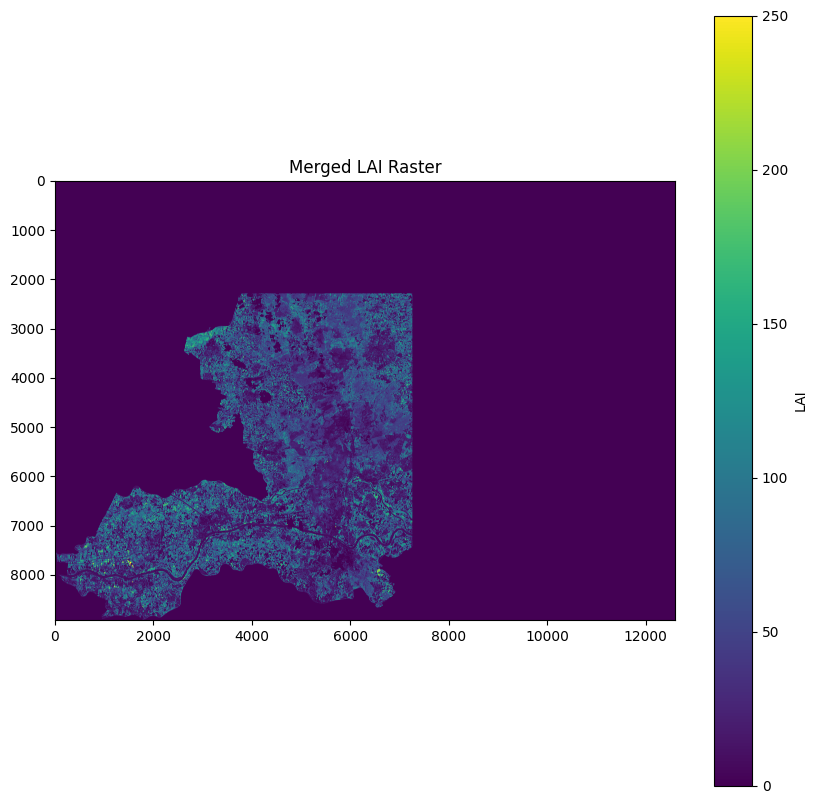

In [14]:
plt.figure(figsize=(10, 10))
plt.imshow(merged_lai, cmap='viridis')
plt.colorbar(label='LAI')
plt.title('Merged LAI Raster')
plt.show()

In [15]:
stats = summarize_dataarray(merged_lai)
for k, v in stats.items():
    print(f"{k}: {v}")

min: 0.0
max: 250.0
mean: 12.299660682678223
std: 28.633989334106445
zero_count: 84666017
nan_count: 0
total_count: 112325886
nonzero_count: 27659869


In [16]:
fapar_tiles = [Path(cfg["paths"]["FAPAR_UGT_path"]), Path(cfg["paths"]["FAPAR_UFT_path"])]
fapar_merged_path = Path(cfg["outputs"]["fapar_merged"])

merged_fapar = merge_tiles(
    tile_paths=fapar_tiles,
    boundary=gelderland.to_crs(cfg["crs"]["target"]),
    target_crs=cfg["crs"]["target"],
    scale_factor=cfg["scaling"]["FAPAR"],
    out_path=fapar_merged_path,
)
check_raster(fapar_merged_path, expected_crs=cfg["crs"]["target"])

2025-09-03 08:54:21 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/FAPAR_T31UFT_2022-05-10_filled_temporal.tiff
2025-09-03 08:54:22 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-09-03 08:54:23 [INFO] src.raster_ops: Loading raster ../data/LAI_FAPAR_temporal_filled/FAPAR_T31UGS_2022-05-10_filled_temporal.tiff
2025-09-03 08:54:24 [INFO] src.raster_ops: Reprojecting clipped raster to EPSG:32631
2025-09-03 08:54:26 [INFO] src.raster_ops: Saving merged raster to ../data/NPP_processed_inputs/output_FAPAR_UTM31N.tif
2025-09-03 08:54:26 [INFO] src.utils: output_FAPAR_UTM31N.tif — Size: 449.4 MB | CRS: EPSG:32631 | Bounds: BoundingBox(left=637303.3115018645, bottom=5733800.013178326, right=763243.3115018645, top=5822990.013178326)


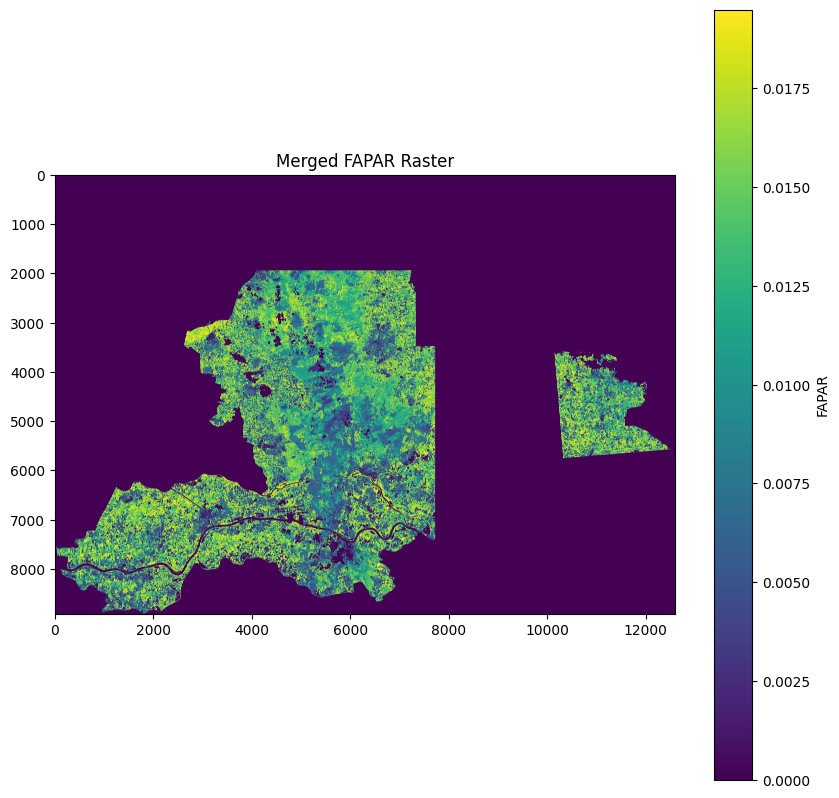

In [17]:
plt.figure(figsize=(10, 10))
plt.imshow(merged_fapar, cmap='viridis')
plt.colorbar(label='FAPAR')
plt.title('Merged FAPAR Raster')
plt.show()

In [18]:
stats = summarize_dataarray(merged_fapar)
for k, v in stats.items():
    print(f"{k}: {v}")


min: 0.0
max: 0.019500000402331352
mean: 0.0032564899884164333
std: 0.005763223394751549
zero_count: 78967593
nan_count: 0
total_count: 112325886
nonzero_count: 33358293


In [19]:
gelderland_wgs84 = gelderland.to_crs("EPSG:4326")
bbox = gelderland_wgs84.total_bounds  
bbox_coords = {
    "lon_min": float(bbox[0]),
    "lon_max": float(bbox[2]),
    "lat_min": float(bbox[1]),
    "lat_max": float(bbox[3]),
}

In [20]:
temp_nc_path = Path(cfg["paths"]["temp_nc_path"])
temp_out_path = Path(cfg["outputs"]["temperature"])

extract_monthly_mean(
    nc_path=temp_nc_path,
    varname="TEMP",
    bbox_coords=bbox_coords,
    time_slice=cfg["npp"]["month_slice"],
    out_crs=cfg["crs"]["target"],
    out_path=temp_out_path,
)
check_raster(temp_out_path, expected_crs=cfg["crs"]["target"])


ValueError: found the following matches with the input file in xarray's IO backends: ['netcdf4', 'h5netcdf']. But their dependencies may not be installed, see:
https://docs.xarray.dev/en/stable/user-guide/io.html 
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html

In [ ]:
ssrd_nc_path = Path(cfg["paths"]["ssrd_nc_path"])
ssrd_out_path = Path(cfg["outputs"]["ssrd"])

extract_ssrd_may_process(
    nc_path=ssrd_nc_path,
    varname="ssrd",
    bbox_coords=bbox_coords,
    time_slice=cfg["npp"]["month_slice"],
    out_crs=cfg["crs"]["target"],
    out_path=ssrd_out_path,
)
check_raster(ssrd_out_path, expected_crs=cfg["crs"]["target"])


In [ ]:
estk_full_path = Path(cfg["paths"]["estk_full_path"])
estk_clipped_path = Path(cfg["estk"]["clipped_path"])
estk_reprojected_path = Path(cfg["estk"]["reprojected_path"])

clip_and_reproject_estk(
    estk_raster_path=estk_full_path,
    boundary_gdf=gelderland,
    clipped_raster_path=estk_clipped_path,
    reprojected_raster_path=estk_reprojected_path,
    target_crs=cfg["crs"]["target"],
)
check_raster(estk_reprojected_path, expected_crs=cfg["crs"]["target"])


In [ ]:
conversion_table = pd.read_excel(cfg["paths"]["conversion_table_path"], engine="openpyxl")
conversion_table.columns = conversion_table.columns.str.strip()
conversion_table = conversion_table.set_index("Pixelwaarde")
conversion_table.head()
#FIXME: The max values are too low thats what is broken, need to decide what other implementation is possible. Maybe check copernicus. 

In [ ]:
npp_output_path = Path(cfg["outputs"]["npp"])

npp_raster = compute_npp(
    lai_path=lai_merged_path,
    fapar_path=fapar_merged_path,
    temp_path=temp_out_path,
    ssrd_path=ssrd_out_path,
    estk_path=estk_reprojected_path,
    conversion_df=conversion_table,
    output_path=npp_output_path,
)

check_raster(npp_output_path, expected_crs=cfg["crs"]["target"])


In [ ]:
npp_raster.plot(cmap="viridis")
plt.title("Computed NPP")
plt.show()

In [ ]:
stats = summarize_dataarray(npp_raster)
for k, v in stats.items():
    print(f"{k}: {v}")

In [ ]:
npp_values = npp_raster.values.flatten()
npp_values = npp_values[~np.isnan(npp_values) & (npp_values != 0)]  # Filter out NaNs and zeros
plt.figure(figsize=(10, 6))
plt.hist(npp_values, bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Frequency of NPP Values')
plt.xlabel('NPP Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


In [ ]:
temp = rxr.open_rasterio("../data/NPP_inputs/Temps/single_level_2m_daily_mean_temp_2022_NL_ERA5.nc", masked=True).squeeze()


In [ ]:
stats = summarize_dataarray(temp)
for k, v in stats.items():
    print(f"{k}: {v}")

In [ ]:
temp #note temp is basically one value for each day

In [ ]:
npp_raster

In [ ]:
#plot timestamp 1 of temp
temp.isel(time=130).plot(cmap="viridis")
plt.title("Temperature at Timestamp 1")
plt.show()